# 44.2 · Epipolar geometry and triangulation

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain epipolar geometry and triangulation using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[07 · Geometric Transformations](../../07-geometric-transformations/README.md), [16 · Camera and Calibration](../../16-camera-and-calibration/README.md), [35 · Optical Flow](../../35-optical-flow/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Three-dimensional vision connects world geometry to image measurements. A single image loses depth through projection; multiple views and assumptions can constrain it. Coordinate frames, units and calibration are as important as the reconstruction algorithm.

## 2. Intuition

Corresponding points lie on related epipolar lines. A fundamental matrix describes the pixel-coordinate constraint; an essential matrix describes calibrated rays. Triangulation finds a 3D point consistent with two camera projections. The lab assumes known calibration and correspondences so that this geometric step can be studied independently.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 44
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\tilde p\sim K[R\mid t]\tilde X
$$

X̃ is a homogeneous world point, R,t map world to camera, K contains intrinsics and p̃ is homogeneous image position. The symbol ∼ means equal up to a nonzero scale. Dividing by depth yields pixel coordinates.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
world = np.array([1.0, 2.0, 4.0, 1.0])
projection = np.column_stack([np.eye(3), np.zeros(3)])
q = projection @ world
pixel = q[:2] / q[2]
assert np.allclose(pixel, [0.25, 0.5])
print(pixel)

[0.25 0.5 ]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference builds four linear equations per correspondence and solves a homogeneous least-squares problem by SVD. OpenCV triangulation is compared under identical camera matrices.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def reconstruction(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    xyz = rng.uniform([-1, -0.6, 3], [1, 0.6, 6], (150, 3))
    k = np.array([[240.0, 0, 160], [0, 240, 120], [0, 0, 1]])
    p1 = k @ np.column_stack([np.eye(3), np.zeros(3)])
    p2 = k @ np.column_stack([np.eye(3), [-0.3, 0, 0]])
    a, b = project(xyz, p1), project(xyz, p2)
    sigma = 0 if lesson == 0 else 0.15 * amount
    noisy_a, noisy_b = a + rng.normal(0, sigma, a.shape), b + rng.normal(0, sigma, b.shape)
    recovered = triangulate(noisy_a, noisy_b, p1, p2)
    cv = cv2.triangulatePoints(p1, p2, noisy_a.T, noisy_b.T)
    cv = (cv[:3] / cv[3]).T
    return Result(
        "44 · Two-view 3D reconstruction",
        points={"True world coordinates (m)": xyz, "Triangulated coordinates (m)": recovered},
        metrics={
            "mean_3d_error_m": float(np.linalg.norm(recovered - xyz, axis=1).mean()),
            "numpy_opencv_max_difference": float(np.abs(recovered - cv).max()),
            "noise_sigma_px": sigma,
        },
        notes="Calibrated rectified cameras and known correspondences. Pose recovery, correspondence search and bundle adjustment are separate problems; this experiment isolates triangulation.",
    )

{
  "mean_3d_error_m": 0.05475153940378559,
  "numpy_opencv_max_difference": 2.9043434324194095e-13,
  "noise_sigma_px": 0.15
}
Calibrated rectified cameras and known correspondences. Pose recovery, correspondence search and bundle adjustment are separate problems; this experiment isolates triangulation.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import triangulate

display(Code(inspect.getsource(triangulate), language="python"))

def triangulate(left_xy, right_xy, p1, p2):
    """Linear triangulation: solve four equations per correspondence by SVD."""
    points = []
    for (u, v), (s, t) in zip(left_xy, right_xy, strict=True):
        design = np.stack(
            [u * p1[2] - p1[0], v * p1[2] - p1[1], s * p2[2] - p2[0], t * p2[2] - p2[1]]
        )
        _, _, vt = np.linalg.svd(design)
        points.append(vt[-1, :3] / vt[-1, 3])
    return np.array(points)

## 8. Experiment

Reduce the baseline while holding pixel noise fixed and measure how 3D error changes. Include points at several depths.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "mean_3d_error_m": 0.05475153940378559,
    "numpy_opencv_max_difference": 2.9043434324194095e-13,
    "noise_sigma_px": 0.15
  },
  "second_seed": {
    "mean_3d_error_m": 0.046205678833601806,
    "numpy_opencv_max_difference": 3.2240876635114546e-13,
    "noise_sigma_px": 0.15
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

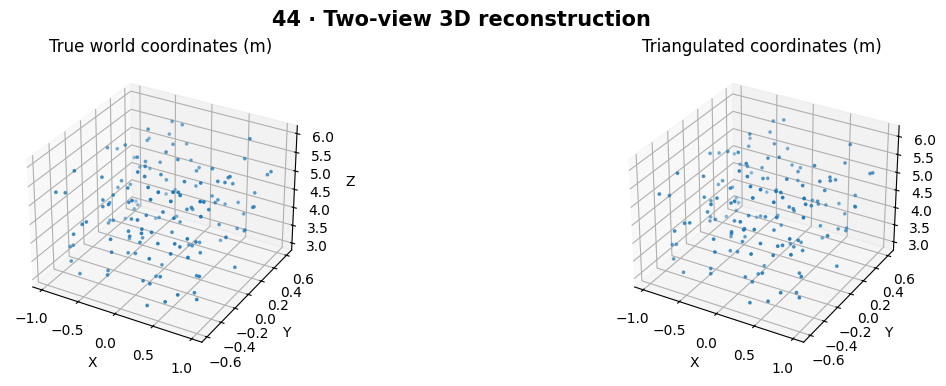

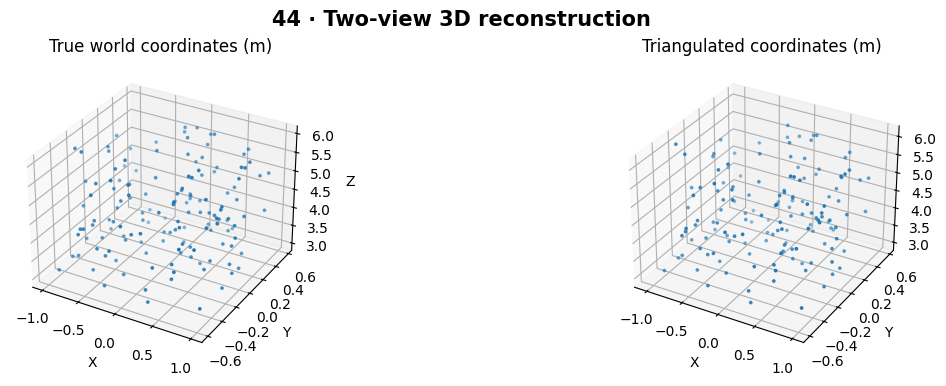

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Two-View Geometry Lab**. Recover geometry while tracking coordinate frames and scale ambiguity. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Low reprojection error alone does not fix scale or guarantee accurate depth. Mixing left-handed and right-handed frames can mirror a reconstruction.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Reduce the baseline while holding pixel noise fixed and measure how 3D error changes. Include points at several depths.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Reconstruct a calibrated synthetic scene, then replace known correspondences with feature matches and quantify the new failure modes.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Corresponding points lie on related epipolar lines. A fundamental matrix describes the pixel-coordinate constraint; an essential matrix describes calibrated rays. Triangulation finds a 3D point consistent with two camera projections. The lab assumes known calibration and correspondences so that this geometric step can be studied independently.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Reprojection and reconstruction error** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)